In [58]:
# %% [markdown]
# # Backtracking Cosmic Rays Through a Turbulent Galactic Magnetic Field
#
# This notebook backpropagates UHECRs from Earth through a turbulent
# Galactic magnetic field to determine their extragalactic arrival directions.
# The isotropic backtracked sample is then re-weighted to imprint a dipolar
# anisotropy matching the Auger-reported extragalactic dipole direction,
# allowing us to study how Galactic deflections modify the observed dipole
# as a function of the magnetic scattering length $L_{\rm scat}$.
#
# **Workflow:**
# 1. Generate an isotropic turbulent magnetic field (Kolmogorov spectrum)
# 2. Backtrack $10^6$ anti-protons from Earth using the Boris-push integrator
# 3. Re-weight the isotropic sample to imprint an extragalactic dipole
# 4. Measure the surviving dipole amplitude via dot-product projection and power spectrum
# 5. Visualise injected vs observed sky maps
#
# **Dependencies:** CRPropa 3.2.1, healpy, cmcrameri, numpy, pandas, matplotlib

# %%
# --- Standard library ---
import sys, time, os, glob

# --- Numerics & data ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib
import matplotlib.pyplot as plt
import healpy as hp
import cmcrameri.cm as cmc

# --- Cosmic ray propagation ---
from crpropa import *

# %% [markdown]
# ## 1. Turbulent Magnetic Field
#
# Isotropic turbulent field with Kolmogorov spectrum ($P(k) \propto k^{-11/3}$).
#
# | Parameter | Value | Notes |
# |-----------|-------|-------|
# | $B_{\rm rms}$ | 2 µG | RMS field strength |
# | Grid | $201^3$ cells, 100 pc spacing | 20.1 kpc box |
# | $l_{\rm min}$ | 450 pc | Minimum turbulence scale |
# | $l_{\rm max}$ | 4000 pc | Maximum turbulence scale |
#
# No regular field component (e.g. JF12) is included — this isolates the
# effect of turbulent deflections on the dipole signal.

# %%
bTur = 2
randomSeed = 10
vgrid = Grid3f(Vector3d(10*kpc, 10*kpc, 10*kpc), 201, 100*pc)
lmin, lmax_turb = 450*pc, 4000*pc

initTurbulence(vgrid, bTur*muG, lmin, lmax_turb, -11./3., randomSeed)
bField_tur = MagneticFieldGrid(vgrid)
field_combined = MagneticFieldList()
field_combined.addField(bField_tur)

In [60]:
%%time

# %% [markdown]
# ## 2. Backtracking Simulation
#
# Anti-protons are emitted inward from a 30 kpc sphere (mimicking isotropic
# extragalactic flux) and backtracked through the turbulent field using the
# **Boris-push** integrator.
#
# - **Detection:** 5 kpc sphere around the GC (particles kept active for multiple crossings)
# - **Termination:** 60 kpc sphere (particles that escape are discarded)

# %%
dd = '/lustre/fs24/group/that/work_vasu/ArrivalDirections/BF_Dipole_Change_Source_BTur_GC/Source_50kpc/'
n = 1_000_000
pid = -nucleusId(1, 1)
meanEnergy = 8.5 * EeV
center = Vector3d(0, 0, 0)
radius = 30
s1 = 5

sim = ModuleList()
sim.add(PropagationBP(field_combined, 1e-4, 0.1*parsec, 100*parsec))

obs_det = Observer()
obs_det.add(ObserverSmallSphere(Vector3d(0, 0, 0)*kpc, s1*kpc))
filename_output = dd + 'test.txt'
obs_det.onDetection(TextOutput(filename_output))
obs_det.setDeactivateOnDetection(False)
sim.add(obs_det)

obs_trash = Observer()
obs_trash.add(ObserverSurface(Sphere(Vector3d(0), (radius*2)*kpc)))
obs_trash.setDeactivateOnDetection(True)
sim.add(obs_trash)

source = Source()
source.add(SourceLambertDistributionOnSphere(center*kpc, radius*kpc, True))
source.add(SourceParticleType(pid))
source.add(SourceEnergy(meanEnergy))

sim.run(source, n)

2026-04-13 14:27:09 [WARNING] ObserverSmallSphere deprecated and will be removed in the future. Replace with ObserverSurface( Sphere(center, radius)).


crpropa::ModuleList: Number of Threads: 64
CPU times: user 46min 40s, sys: 940 ms, total: 46min 41s
Wall time: 56.7 s


In [61]:
%%time

# %% [markdown]
# ## 3. Load Simulation Output
#
# CRPropa `TextOutput` writes 14 header lines. Column conventions:
# - No suffix (`E`, `Px`, ...): state at detection
# - Suffix `0`: state at detection (same for Observer output)
# - Suffix `1`: state at source (injection on the 30 kpc sphere)

# %%
cols = ['D','z','SN','ID','E','X','Y','Z','Px','Py','Pz',
        'SN0','ID0','E0','X0','Y0','Z0','P0x','P0y','P0z',
        'SN1','ID1','E1','X1','Y1','Z1','P1x','P1y','P1z','W']

data_hdf = pd.read_csv(filename_output, delimiter="\t", header=None,
                        skiprows=14, on_bad_lines='skip', engine='python')
data_hdf.columns = cols
print(f"Detected events: {len(data_hdf)}")

Detected events: 27851
CPU times: user 814 ms, sys: 40.9 ms, total: 855 ms
Wall time: 547 ms


In [62]:
# %% [markdown]
# ## 4. Dipole Re-weighting
#
# The isotropic backtracked sample is re-weighted to imprint a dipolar
# anisotropy in the Auger-reported extragalactic dipole direction
# $(l, b) = (309.5°, -19.4°)$:
#
# $$w_i = 1 + \sqrt{3} \; (\hat{p}_{\rm ini} \cdot \hat{d}_{\rm dipole})$$
#
# The observed dipole amplitude is then measured as:
# $$d_{\rm obs} = 3 \, \frac{\sum_i (\hat{p}_{\rm fin} \cdot \hat{d}) \, w_i}{\sum_i w_i}$$

# %%
%%time
EG_lat, EG_lon = np.radians(-19.42), np.radians(-(360 - 309.516))

d_dip = np.array([np.cos(EG_lat)*np.cos(EG_lon),
                   np.cos(EG_lat)*np.sin(EG_lon),
                   np.sin(EG_lat)])

dip_amp = np.sqrt(3)

pxi = data_hdf['P0x'].values.astype(float)
pyi = data_hdf['P0y'].values.astype(float)
pzi = data_hdf['P0z'].values.astype(float)

pxf = data_hdf['Px'].values.astype(float)
pyf = data_hdf['Py'].values.astype(float)
pzf = data_hdf['Pz'].values.astype(float)

# Galactic coordinates (backtracking: arrival direction = -p)
lon_ini = np.arctan2(-pyi, -pxi) - np.pi
lat_ini = np.pi/2 - np.arccos(-pzi / np.sqrt(pxi**2 + pyi**2 + pzi**2))

lon_fin = np.arctan2(-pyf, -pxf) - np.pi
lat_fin = np.pi/2 - np.arccos(-pzf / np.sqrt(pxf**2 + pyf**2 + pzf**2))

# Dipole weights and projected amplitude
dot_ini = pxi*d_dip[0] + pyi*d_dip[1] + pzi*d_dip[2]
dot_fin = pxf*d_dip[0] + pyf*d_dip[1] + pzf*d_dip[2]

wt_dip = 1.0 + dip_amp * dot_ini
wt_iso = np.ones(len(data_hdf))

data_len = len(data_hdf)
proj_dip = 3 * np.sum(dot_fin * wt_dip) / np.sum(wt_dip)
proj_iso = 3 * np.sum(dot_fin * wt_iso) / np.sum(wt_iso)

print("=" * 50)
print("WITH DIPOLE WEIGHTING")
print(f"  Projected dipole amplitude      = {proj_dip:.4e}")
print(f"  sqrt(N)/sum(w)                  = {np.sqrt(data_len)/np.sum(wt_dip):.4e}")
print(f"  1/sqrt(N)                       = {1/np.sqrt(data_len):.4e}")
print()
print("NO DIPOLE (isotropic control)")
print(f"  Projected dipole amplitude      = {proj_iso:.4e}")
print(f"  1/sqrt(N)                       = {1/np.sqrt(data_len):.4e}")
print("=" * 50)

# Fill HEALPix maps
M_dip_initial = ParticleMapsContainer()
M_dip_final   = ParticleMapsContainer()

for i in range(data_len):
    M_dip_initial.addParticle(pid, meanEnergy, lon_ini[i], lat_ini[i], wt_dip[i])
    M_dip_final.addParticle(pid, meanEnergy, lon_fin[i], lat_fin[i], wt_dip[i])

Map_dip_initial = M_dip_initial.getMap(int(pid), meanEnergy)
Map_dip_final   = M_dip_final.getMap(int(pid), meanEnergy)

UsageError: Line magic function `%%time` not found.


In [ ]:
# %% [markdown]
# ## 5. Angular Power Spectrum
#
# Normalised power spectrum $C'_\ell = C_\ell / \sum C_\ell$ and multipole
# coefficients $a_\ell = \sqrt{(2\ell+1)/4\pi} \sqrt{C'_\ell}$.
# The ratio $a_1/a_0$ quantifies how much of the injected dipole survives
# Galactic deflection.

# %%
lmax_ps = 7

Cl_final = hp.anafast(Map_dip_final, lmax=lmax_ps)
norm_Cl = Cl_final / np.sum(Cl_final)

ells = np.arange(lmax_ps + 1)
a_l = np.sqrt((2*ells + 1) / (4*np.pi)) * np.sqrt(norm_Cl)

print(f"a_1/a_0 (dipole/monopole) = {a_l[1]/a_l[0]:.3e}")
print(f"a_1/sum(a_l)              = {a_l[1]/np.sum(a_l):.3e}")
print(f"a_2/a_0 (quadrupole)      = {a_l[2]/a_l[0]:.3e}")

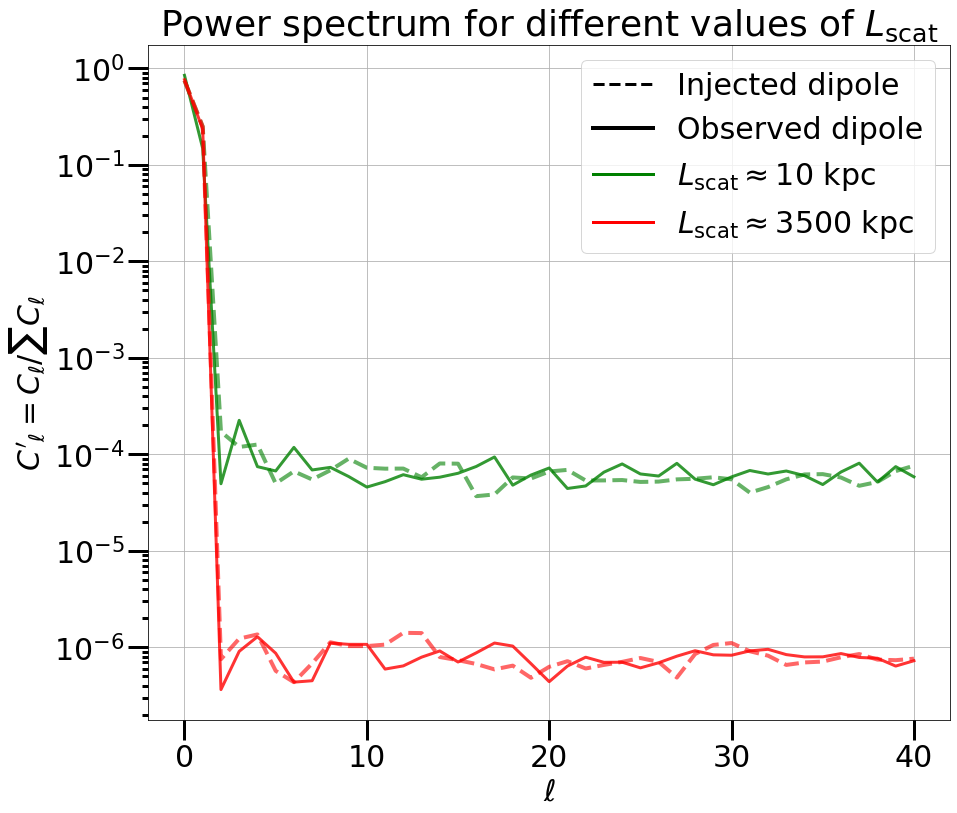

In [63]:
# %% [markdown]
# ## 6. Power Spectrum Comparison
#
# Comparing $C'_\ell$ for two scattering lengths:
# - **Green:** $L_{\rm scat} \approx 10$ kpc (this simulation, strong deflection)
# - **Red:** $L_{\rm scat} \approx 3500$ kpc (pre-computed reference, weak deflection)
#
# Dashed = injected, solid = observed. Strong fields transfer power from
# $\ell = 1$ (dipole) into higher multipoles.

# %%
fig, ax = plt.subplots(figsize=(14, 12))
lmax_plot = 40

Cl_inj = hp.anafast(Map_dip_initial, lmax=lmax_plot)
Cl_obs = hp.anafast(Map_dip_final, lmax=lmax_plot)
norm_Cl_inj = Cl_inj / np.sum(Cl_inj)
norm_Cl_obs = Cl_obs / np.sum(Cl_obs)
np.savetxt('PS_inj_10.txt', norm_Cl_inj)
np.savetxt('PS_dip_10.txt', norm_Cl_obs)

ax.plot(norm_Cl_inj, ls='--', lw=4, c='g', alpha=0.6)
ax.plot(norm_Cl_obs, lw=3, c='g', alpha=0.8)

ref_path = '/lustre/fs24/group/that/work_vasu/ArrivalDirections/BF_Dipole_Change_Source_BTur_GC/Source_50kpc/30kpc/2.7/'
PS_inj_3500 = np.loadtxt(ref_path + 'PS_inj_3500.txt')
PS_dip_3500 = np.loadtxt(ref_path + 'PS_dip_3500.txt')

ax.plot(PS_inj_3500, ls='--', lw=4, c='r', alpha=0.6)
ax.plot(PS_dip_3500, lw=3, c='r', alpha=0.8)

ax.legend([
    plt.Line2D([], [], color='k', ls='--', lw=3),
    plt.Line2D([], [], color='k', ls='-',  lw=4),
    plt.Line2D([], [], color='g', ls='-',  lw=3),
    plt.Line2D([], [], color='r', ls='-',  lw=3),
], [
    'Injected dipole',
    'Observed dipole',
    r'$L_{\rm scat} \approx 10$ kpc',
    r'$L_{\rm scat} \approx 3500$ kpc',
])

ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r"$C'_{\ell} = C_\ell / \sum C_\ell$")
ax.set_title(r'Power spectrum for different values of $L_{\rm scat}$')
ax.set_yscale('log')
ax.grid(True)
ax.tick_params(which='minor', width=3, length=6)
ax.tick_params(which='major', width=3, length=20)
plt.tight_layout()

/lustre/fs21/group/that/vasu/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


<Figure size 1440x960 with 0 Axes>

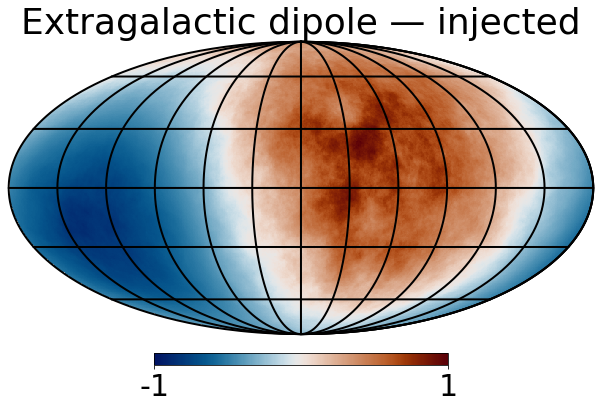

<Figure size 1440x960 with 0 Axes>

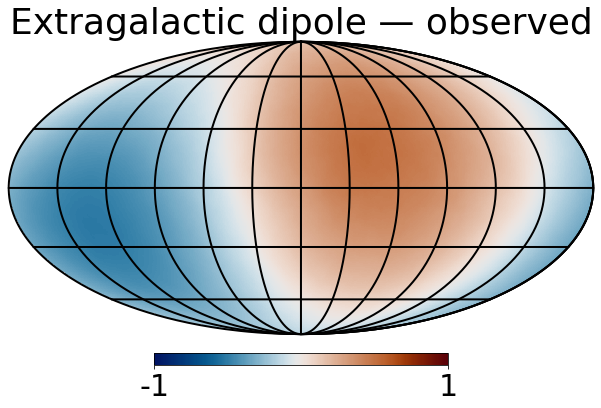

In [65]:
# %% [markdown]
# ## 7. Sky Maps
#
# Mollweide projections of dipole-weighted arrival directions, smoothed
# with a top-hat beam and monopole-subtracted. Both maps are normalised
# to the peak of the injected map so the colour scale shows the
# suppression factor directly.
#
# - **Injected** (10° smoothing): clean extragalactic dipole before deflection
# - **Observed** (45° smoothing): dipole after Galactic propagation

# %%
def top_hat_beam(radius, lmax):
    """Beam window function for a top-hat of angular radius `radius` (rad)."""
    b = np.linspace(0.0, np.pi, 10000)
    bw = np.where(np.abs(b) <= radius, 1, 0)
    return hp.sphtfunc.beam2bl(bw, b, lmax=lmax)

def smoothed_map(hp_map, radius_deg, nside):
    """Smooth a HEALPix map with a top-hat beam, normalised by solid angle."""
    radius = np.radians(radius_deg)
    solid_angle = 2.0 * np.pi * (1.0 - np.cos(radius))
    return hp.smoothing(hp_map, beam_window=top_hat_beam(radius, nside), verbose=False) / solid_angle

# %%
matplotlib.rcParams.update({'font.size': 30})
nside = 512

# Injected dipole map
sm_inj = smoothed_map(Map_dip_initial, radius_deg=10, nside=nside)
sm_inj_centred = sm_inj - hp.fit_monopole(sm_inj)
norm_map = np.max(sm_inj_centred)

fig = plt.figure(figsize=(20, 20/(3/2)))
hp.mollview(sm_inj_centred / norm_map, cmap='cmc.vik',
            title=r'Extragalactic dipole — injected', min=-1, max=1)
hp.graticule(linestyle='-', color='black')
for line in plt.gca().get_lines():
    line.set_linewidth(2.0)
plt.savefig('Ext_EG_inj_7.7.png', dpi=300, bbox_inches='tight')

# Observed dipole map (larger smoothing — signal is suppressed)
sm_obs = smoothed_map(Map_dip_final, radius_deg=45, nside=nside)
sm_obs_centred = sm_obs - hp.fit_monopole(sm_obs)

fig = plt.figure(figsize=(20, 20/(3/2)))
hp.mollview(sm_obs_centred / norm_map, cmap='cmc.vik',
            title=r'Extragalactic dipole — observed', min=-1, max=1)
hp.graticule(linestyle='-', color='black')
for line in plt.gca().get_lines():
    line.set_linewidth(2.0)
plt.tight_layout()